In [82]:
import pandas as pd
import os.path as op
import numpy as np
from stress_risk.utils.data import get_all_behavior
from tqdm.contrib.itertools import product
import matplotlib.pyplot as plt
import pingouin
import seaborn as sns

In [83]:
def get_decoding_info(subject, session, pca_confounds=False, denoise=False, smoothed=False, bids_folder='/data/ds-stressrisk', mask='NPC_R', n_voxels=100):

    key = 'decoded_pdfs.volume'

    subject = f'{subject:02d}'

    if denoise:
        key += '.denoise'

    if smoothed:
        key += '.smoothed'

    if pca_confounds and not denoise:
        key += '.pca_confounds'

    pdf = op.join(bids_folder, 'derivatives', key, f'sub-{subject}', 'func', f'sub-{subject}_ses-{session}_mask-{mask}_nvoxels-{n_voxels}_space-T1w_pars.tsv')

    if op.exists(pdf):
        pdf = pd.read_csv(pdf, sep='\t', index_col=[0])
        pdf.columns = pdf.columns.astype(float)

        E = (pdf*pdf.columns.values[np.newaxis, :] / pdf.sum(1).values[:, np.newaxis]).sum(1)

        E = pd.concat((E,), keys=[(int(subject), int(session), 'pca_confounds' if pca_confounds else 'no pca', 'GLMstim' if denoise else "glm", 'smoothed' if smoothed else 'not smoothed', mask, n_voxels)],
        names=['subject', 'session', 'pca', 'glm', 'smoothed', 'mask', 'n_voxels']).to_frame('E')

        return E
    else:
        print(pdf)
        return pd.DataFrame(np.zeros((0, 0)))

In [84]:
subjects = list(range(1, 49)) + [116, 150, 141, 152, 130, 163, 165]
sessions = [1]
pca_confounds = [True]
denoise = [True]
smoothed = [False]
masks = ['NPC_R']
n_voxels = [50, 100, 250]

pred = []
for (sub, session, pcac, den, smooth, mask, nv) in product(subjects, sessions, pca_confounds, denoise, smoothed, masks, n_voxels):
    pred.append(get_decoding_info(sub, session, pcac, den, smooth, '/data/ds-stressrisk', mask, nv))

  0%|          | 0/165 [00:00<?, ?it/s]

/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-11/func/sub-11_ses-1_mask-NPC_R_nvoxels-50_space-T1w_pars.tsv
/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-11/func/sub-11_ses-1_mask-NPC_R_nvoxels-100_space-T1w_pars.tsv
/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-11/func/sub-11_ses-1_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv
/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-15/func/sub-15_ses-1_mask-NPC_R_nvoxels-50_space-T1w_pars.tsv
/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-15/func/sub-15_ses-1_mask-NPC_R_nvoxels-100_space-T1w_pars.tsv
/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-15/func/sub-15_ses-1_mask-NPC_R_nvoxels-250_space-T1w_pars.tsv
/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-20/func/sub-20_ses-1_mask-NPC_R_nvoxels-50_space-T1w_pars.tsv
/data/ds-stressrisk/derivatives/decoded_pdfs.volume.denoise/sub-20/func/sub-20_ses-1_mask-NPC_R_nvoxels-100_space-

In [85]:
df = get_all_behavior(drop_no_responses=False)

/Users/gdehol/git/stress_risk/stress_risk/utils/data.py:25: FutureWarning: In a future version, object-dtype columns with all-bool values will not be included in reductions with bool_only=True. Explicitly cast to bool dtype instead.
  return pd.concat(behavior)


In [86]:
df.index.unique('subject')

Int64Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
             14,  16,  17,  18,  19,  21,  22,  23,  24,  25,  26,  27,  28,
             29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
             42,  43,  44,  45,  46,  47,  48, 101, 116, 130, 141, 150, 152,
            163, 165],
           dtype='int64', name='subject')

In [87]:
pred = pd.concat(pred)

In [88]:
pred.index.unique(level='subject')

Int64Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  12,  13,  14,
             16,  17,  18,  19,  21,  22,  23,  24,  25,  26,  28,  29,  30,
             31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,
             44,  45,  46,  47,  48, 116, 150, 141, 152, 130, 163, 165],
           dtype='int64', name='subject')

In [89]:
pred = pred.join(df, how='inner')

In [90]:
r1 = pred.groupby(['subject', 'pca', 'glm', 'smoothed', 'mask', 'n_voxels']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
r2_ = pred.groupby(['subject', 'pca', 'glm', 'smoothed', 'mask', 'n_voxels', 'run']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
r2 = r2_.groupby(['subject', 'pca', 'glm', 'smoothed', 'mask', 'n_voxels']).mean()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_95917/2777660657.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  r2 = r2_.groupby(['subject', 'pca', 'glm', 'smoothed', 'mask', 'n_voxels']).mean()


In [91]:
import seaborn as sns

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_95917/2699782525.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 67)` for the same effect.

  fac = sns.catplot(x='n_voxels', y='r', hue='glm',data=r1.reset_index(), col='mask', kind='bar', row='smoothed', dodge=True, ci=67)


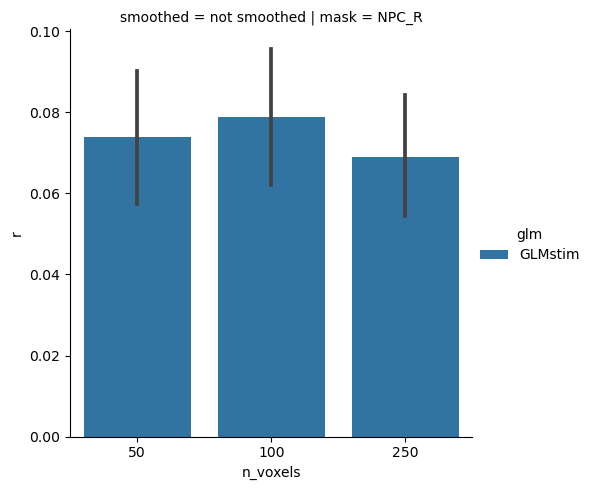

In [92]:
fac = sns.catplot(x='n_voxels', y='r', hue='glm',data=r1.reset_index(), col='mask', kind='bar', row='smoothed', dodge=True, ci=67)

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_95917/1537915715.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 67)` for the same effect.

  fac = sns.catplot(x='n_voxels', y='r', hue='glm',data=r2.reset_index(), col='mask', kind='bar', row='smoothed', dodge=True, ci=67)


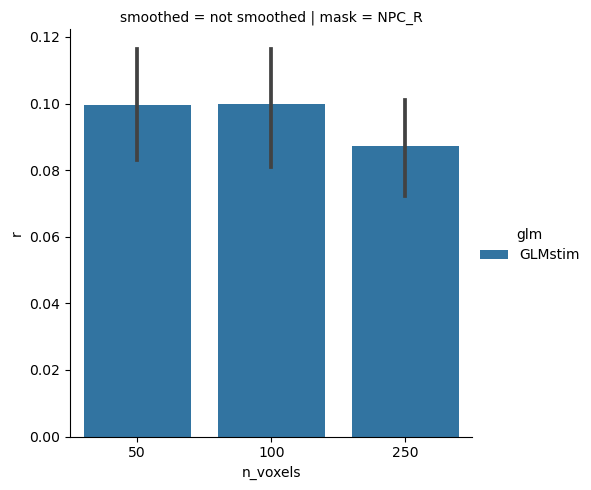

In [93]:
fac = sns.catplot(x='n_voxels', y='r', hue='glm',data=r2.reset_index(), col='mask', kind='bar', row='smoothed', dodge=True, ci=67)

In [94]:
pingouin.ttest(r2.unstack('n_voxels')['r'][50],0)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.670842,50,two-sided,7.075257e-07,"[0.06, 0.13]",0.794077,2.256e+04,0.99984


In [95]:
import pingouin

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/axisgrid.py:745: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  plot_args = [v for k, v in plot_data.iteritems()]


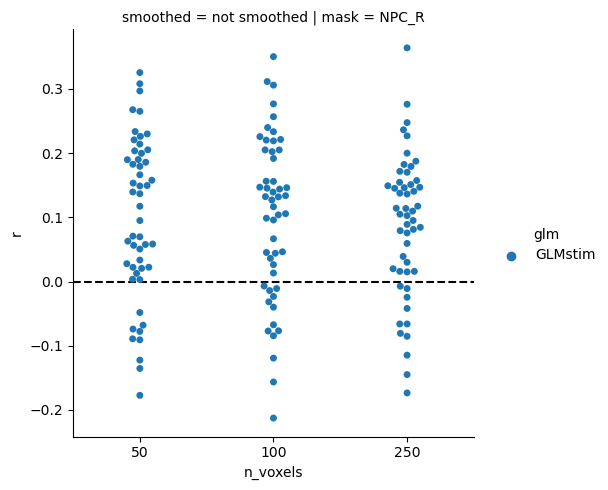

In [96]:
fac = sns.catplot(x='n_voxels', y='r', hue='glm',data=r2.reset_index(), col='mask', kind='swarm', row='smoothed', dodge=True)

fac.map(lambda *args, **kwargs: plt.axhline(0, c='k', ls='--'))

In [97]:
(r2.xs('GLMstim', 0, 'glm').xs(100, 0, 'n_voxels')['r'] > 0).mean()

0.7450980392156863

In [98]:
r2.unstack(['n_voxels'])['r'].corr()

n_voxels,50,100,250
n_voxels,,,
50,1.000000,0.735926,0.528805
100,0.735926,1.000000,0.788325
250,0.528805,0.788325,1.000000


In [99]:
r_final = r2.xs(100, 0, 'n_voxels').droplevel([1, 2, 3, 4])[['r']]

r_final.to_csv('/data/ds-stressrisk/derivatives/decoding_accuracy_ses-1.tsv', sep='\t')

In [100]:
pingouin.ttest(r_final['r'], 0.0)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,5.590028,50,two-sided,9.422342e-07,"[0.06, 0.14]",0.78276,1.725e+04,0.999784


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_95917/155108199.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(r_final,bins=20)


<AxesSubplot: ylabel='Density'>

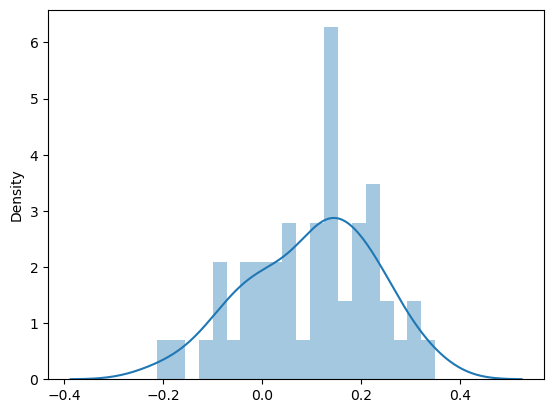

In [101]:
sns.distplot(r_final,bins=20)

In [102]:
rnp = pd.read_csv('/Users/gdehol/git/stress_risk/stress_risk/subject_selection/subjectwise_rnp.tsv', sep='\t', index_col=0)
gamma = pd.read_csv('/Users/gdehol/git/stress_risk/stress_risk/subject_selection/subjectwise_gamma.tsv', sep='\t', index_col=0)

In [103]:
r_final = r_final.join(rnp)

In [104]:
r_final.to_csv('subject_stats.tsv', sep='\t')

In [105]:
r_final = r_final.join(gamma)

In [106]:
r_final

,r,rnp,gamma
subject,,,
1,0.220240,0.609986,3.019802
2,0.105622,0.542685,2.750930
3,-0.077133,0.499765,1.823213
4,-0.014096,0.389723,2.117380
5,0.116511,0.571540,2.799628
6,0.305833,0.566016,2.747944
7,0.026288,0.526097,2.291501
8,-0.119301,0.294766,0.247815
9,0.146086,0.538337,2.122095


In [107]:
pingouin.corr(r_final['r'], r_final['gamma'])

,n,r,CI95%,p-val,BF10,power
pearson,51,0.305216,"[0.03, 0.54]",0.029413,1.752,0.595909


In [108]:
pingouin.corr(r_final['r'], r_final['rnp'])

,n,r,CI95%,p-val,BF10,power
pearson,51,0.084383,"[-0.2, 0.35]",0.556047,0.207,0.090544
